#  Task 1 — Sales & Demand Forecasting
**Future Interns | Machine Learning Track | FUTURE_ML_01**

---

### Objective
Build a model to forecast future sales or demand using historical business data.

### Skills Covered
- Time-series analysis & feature engineering
- Regression and time-series forecasting models
- Model evaluation and error analysis
- Business-ready visual forecast output

### Tools Used
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Scikit-learn`

In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd                          # For working with tables (DataFrames)
import numpy as np                           # For math operations
import matplotlib.pyplot as plt              # For basic charts
import seaborn as sns                        # For prettier charts
from sklearn.linear_model import LinearRegression   # Our forecasting model
from sklearn.ensemble import RandomForestRegressor  # A more powerful model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')            # Suppress unimportant warnings

# Make charts look nice
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')


print('✅ All libraries imported successfully!')

---
## Step 1: Load & Explore the Data
Before building anything, we need to **understand our data**.  
This is called **Exploratory Data Analysis (EDA)**.

In [3]:
#load the datasetadwasim/Desktop/ML TASK/Superstore.csv")
# Show the first 5 rows — always start here!
df = pd.read_csv('Superstore.csv', encoding='latin-1')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 9800 rows × 18 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
#check column and data types
print('Column names and types:')
print(df.dtypes)
print()
# Check for missing values — missing data is a very common problem!
#print('Missing values per column:')
#print(df.insull().sum())

Column names and types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object



In [5]:
#Summarry statistics — min, max, average of numeric columns
print('Summary statistics:')
df.describe()

Summary statistics:


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


---
##  Step 2: Data Cleaning
Real-world data is messy. We need to:
- Convert dates from text to actual date objects
- Remove duplicates
- Handle any missing values

In [6]:
# Convert Order Date from text (string) to a real date
# pd.to_datetime() is the magic function for this
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
# Sort by date (oldest first)
df = df.sort_values('Order Date').reset_index(drop=True)

# Remove duplicate rows (if any)
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f'Removed {before - after}duplicate rows ')

print(f'Data range:{df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
print(f'Total orders: {len(df):,}')









Removed 0duplicate rows 
Data range:2015-01-03 → 2018-12-30
Total orders: 9,800


---
##  Step 3: Feature Engineering
**Feature engineering** means creating new columns from existing data that help the model learn patterns.

For time-series forecasting, we extract things like:
- Which **month** is it? (December = high sales)
- Which **quarter**?
- Which **year**?
- **Rolling averages** — average sales over the past 3 months

In [7]:
# Step 3a: Aggregate sales by month
# We group all orders by Year-Month and sum up the sales

df['YearMonth'] = df['Order Date'].dt.to_period('M')  # e.g. '2015-01'

monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales.columns = ['YearMonth', 'Total_Sales']
monthly_sales['YearMonth_dt'] = monthly_sales['YearMonth'].dt.to_timestamp()

print(f'Monthly data: {len(monthly_sales)} months')
monthly_sales.head()

Monthly data: 48 months


,YearMonth,Total_Sales,YearMonth_dt
0,2015-01,14205.707,2015-01-01
1,2015-02,4519.892,2015-02-01
2,2015-03,55205.797,2015-03-01
3,2015-04,27906.855,2015-04-01
4,2015-05,23644.303,2015-05-01


In [12]:
# Step 3b: Create time-based features
monthly_sales['Month']       = monthly_sales['YearMonth_dt'].dt.month
monthly_sales['Year']        = monthly_sales['YearMonth_dt'].dt.year
monthly_sales['Quarter']     = monthly_sales['YearMonth_dt'].dt.quarter
monthly_sales['Month_Index'] = range(len(monthly_sales))

# Rolling averages
monthly_sales['Rolling_3M'] = monthly_sales['Total_Sales'].shift(1).rolling(3).mean()
monthly_sales['Rolling_6M'] = monthly_sales['Total_Sales'].shift(1).rolling(6).mean()

# Lag features
monthly_sales['Lag_1']  = monthly_sales['Total_Sales'].shift(1)
monthly_sales['Lag_12'] = monthly_sales['Total_Sales'].shift(12)

# Check how many rows we have BEFORE dropping NaN
print(f"Rows before dropna: {len(monthly_sales)}")
print(f"Columns: {monthly_sales.columns.tolist()}")
print(f"NaN counts:\n{monthly_sales.isnull().sum()}")

# Only drop rows where Lag_1 and Rolling_3M are NaN
# DON'T drop on Lag_12 if dataset is small
cols_to_check = ['Rolling_3M', 'Rolling_6M', 'Lag_1']
monthly_sales_clean = monthly_sales.dropna(subset=cols_to_check).reset_index(drop=True)

# Fill any remaining NaN in Lag_12 with the column mean
monthly_sales_clean['Lag_12'] = monthly_sales_clean['Lag_12'].fillna(
    monthly_sales_clean['Total_Sales'].mean()
)

print(f"\nRows after dropna: {len(monthly_sales_clean)}")
print(f" Columns ready: {monthly_sales_clean.columns.tolist()}")

Rows before dropna: 48
Columns: ['YearMonth', 'Total_Sales', 'YearMonth_dt', 'Month', 'Year', 'Quarter', 'Month_Index', 'Rolling_3M', 'Rolling_6M', 'Lag_1', 'Lag_2', 'Lag_12']
NaN counts:
YearMonth        0
Total_Sales      0
YearMonth_dt     0
Month            0
Year             0
Quarter          0
Month_Index      0
Rolling_3M       3
Rolling_6M       6
Lag_1            1
Lag_2           12
Lag_12          12
dtype: int64

Rows after dropna: 42
 Columns ready: ['YearMonth', 'Total_Sales', 'YearMonth_dt', 'Month', 'Year', 'Quarter', 'Month_Index', 'Rolling_3M', 'Rolling_6M', 'Lag_1', 'Lag_2', 'Lag_12']


---
##  Step 4: Visualise the Data
Always plot your data before modelling. You'll spot trends and seasonality visually.

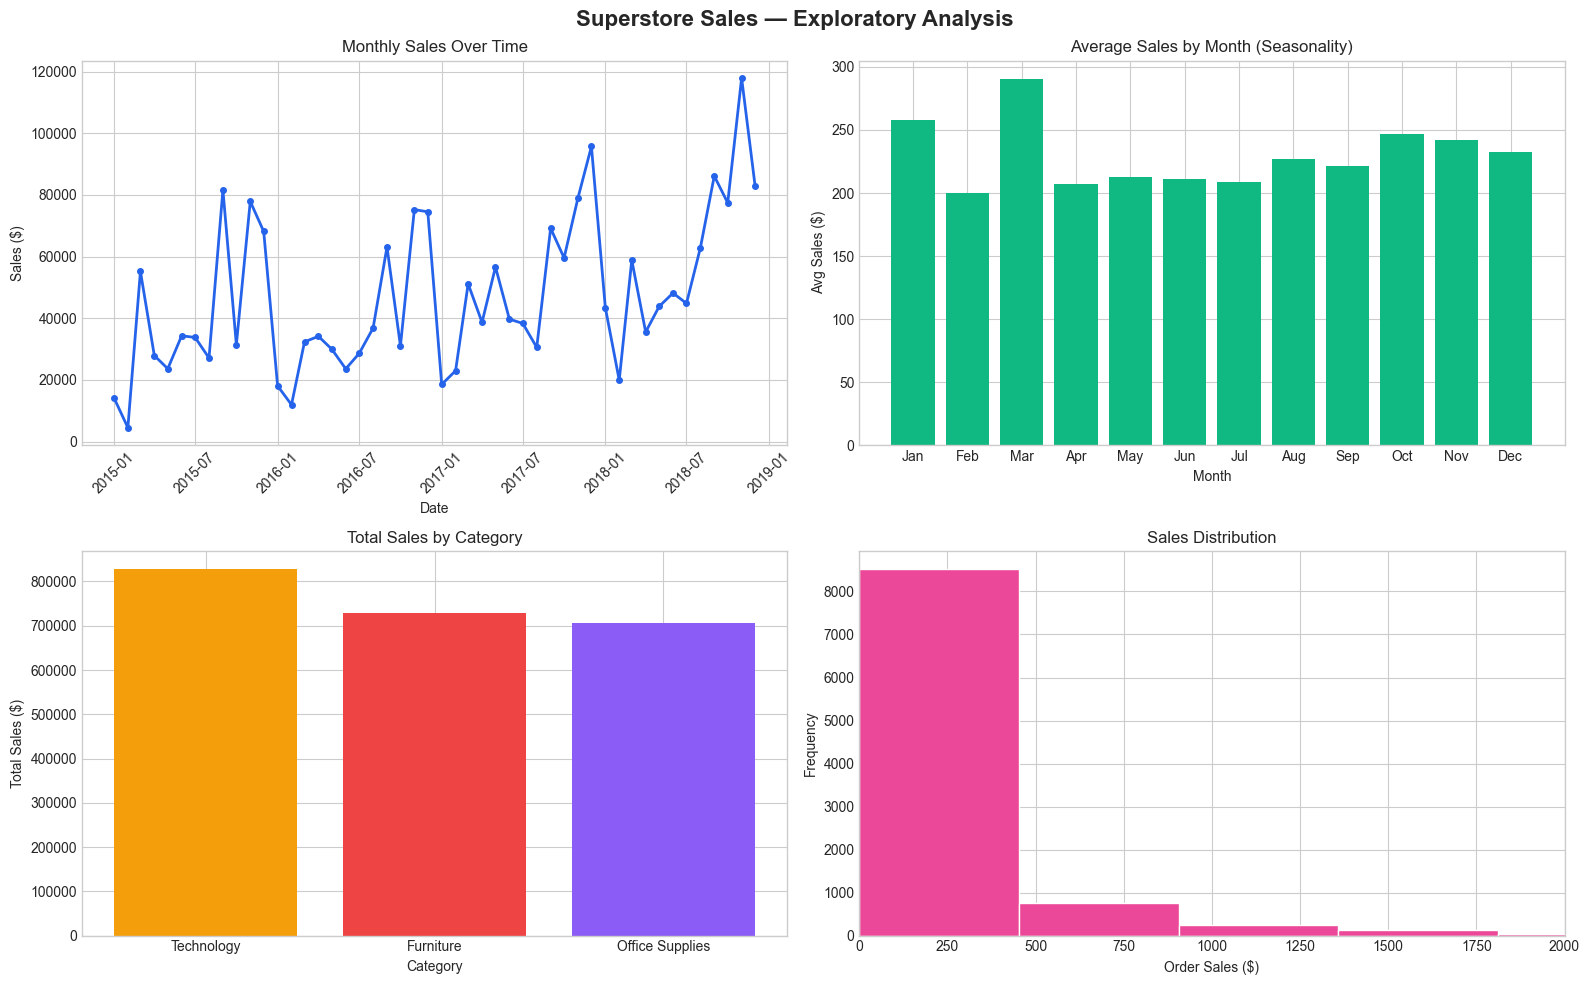

💾 Chart saved as eda_charts.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Superstore Sales — Exploratory Analysis', fontsize=16, fontweight='bold')

# Chart 1: Monthly Sales Over Time
axes[0,0].plot(monthly_sales['YearMonth_dt'], monthly_sales['Total_Sales'],
               color='#2563EB', linewidth=2, marker='o', markersize=4)
axes[0,0].set_title('Monthly Sales Over Time')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Sales ($)')
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2: Average Sales by Month (seasonality)
avg_by_month = df.groupby(df['Order Date'].dt.month)['Sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0,1].bar(month_names, avg_by_month.values, color='#10B981')
axes[0,1].set_title('Average Sales by Month (Seasonality)')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Avg Sales ($)')

# Chart 3: Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[1,0].bar(cat_sales.index, cat_sales.values, color=['#F59E0B','#EF4444','#8B5CF6'])
axes[1,0].set_title('Total Sales by Category')
axes[1,0].set_xlabel('Category')
axes[1,0].set_ylabel('Total Sales ($)')

# Chart 4: Sales Distribution (histogram)
axes[1,1].hist(df['Sales'], bins=50, color='#EC4899', edgecolor='white')
axes[1,1].set_title('Sales Distribution')
axes[1,1].set_xlabel('Order Sales ($)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_xlim(0, 2000)  # Focus on most orders

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart saved as eda_charts.png')

---
##  Step 5: Build & Train the Forecasting Model

We'll train **two models** and compare them:
1. **Linear Regression** — simple, draws a best-fit line
2. **Random Forest** — powerful, uses many decision trees

We split data into:
- **Training set** (80%): the model learns from this
- **Test set** (20%): we check how well it predicts unseen data

In [14]:
# Define features and target
feature_cols = ['Month', 'Year', 'Quarter', 'Month_Index', 'Rolling_3M', 'Rolling_6M', 'Lag_1', 'Lag_12']

# Verify all columns exist before proceeding
missing = [c for c in feature_cols if c not in monthly_sales_clean.columns]
if missing:
    print(f"Missing columns: {missing}")
else:
    print("All feature columns found!")

X = monthly_sales_clean[feature_cols]
y = monthly_sales_clean['Total_Sales']

# Split into train (80%) and test (20%) — time-ordered, no shuffling!
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Model 2: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print('\n Both models trained successfully!')

All feature columns found!
Training samples: 33
Testing samples:  9

 Both models trained successfully!


---
##  Step 6: Evaluate the Models

We use three metrics:
| Metric | What it means | Lower = Better? |
|--------|--------------|----------------|
| **MAE** | Average error in dollars | ✅ Yes |
| **RMSE** | Penalises large errors more | ✅ Yes |
| **R²** | % of variance explained (0–1) | ❌ Higher is better |

In [16]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n {name}')
    print(f'   MAE  = ${mae:,.0f}  (avg error per month)')
    print(f'   RMSE = ${rmse:,.0f}')
    print(f'   R²   = {r2:.3f}  ({r2*100:.1f}% variance explained)')
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = evaluate('Linear Regression', y_test, lr_preds)
rf_mae, rf_rmse, rf_r2 = evaluate('Random Forest',     y_test, rf_preds)

best = 'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'
print(f'\n Best model: {best}')


 Linear Regression
   MAE  = $14,608  (avg error per month)
   RMSE = $17,371
   R²   = 0.525  (52.5% variance explained)

 Random Forest
   MAE  = $13,684  (avg error per month)
   RMSE = $16,614
   R²   = 0.565  (56.5% variance explained)

 Best model: Random Forest


---
##  Step 7: Forecast Visualisation
Now let's plot the actual vs predicted sales — the most important chart for your submission.

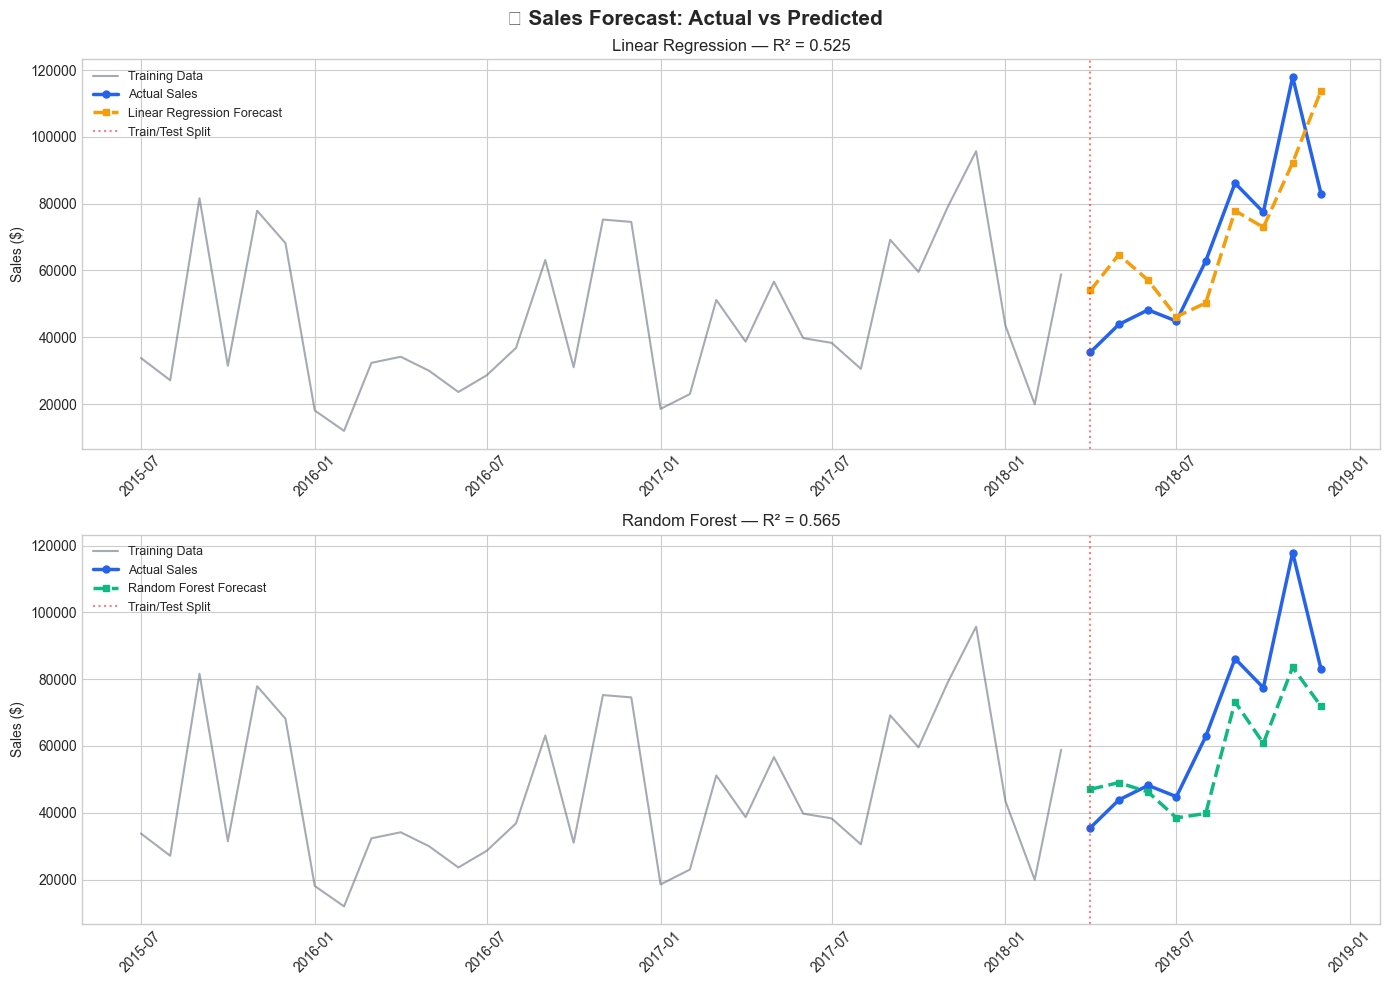

 Saved as forecast_results.png


In [17]:
test_dates = monthly_sales_clean['YearMonth_dt'].iloc[split_idx:]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('🔮 Sales Forecast: Actual vs Predicted', fontsize=15, fontweight='bold')

for ax, preds, title, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['#F59E0B', '#10B981']
):
    # Full history
    all_dates = monthly_sales_clean['YearMonth_dt']
    ax.plot(all_dates.iloc[:split_idx], y_train,
            color='#6B7280', linewidth=1.5, label='Training Data', alpha=0.6)
    ax.plot(test_dates, y_test,
            color='#2563EB', linewidth=2.5, marker='o', markersize=5, label='Actual Sales')
    ax.plot(test_dates, preds,
            color=color, linewidth=2.5, marker='s', markersize=5, linestyle='--', label=f'{title} Forecast')
    ax.axvline(x=test_dates.iloc[0], color='red', linestyle=':', alpha=0.5, label='Train/Test Split')
    ax.set_title(f'{title} — R² = {r2_score(y_test, preds):.3f}', fontsize=12)
    ax.set_ylabel('Sales ($)')
    ax.legend(loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('forecast_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved as forecast_results.png')

---
##  Step 8: Feature Importance (Random Forest)
Random Forest tells us which features mattered most for predictions.

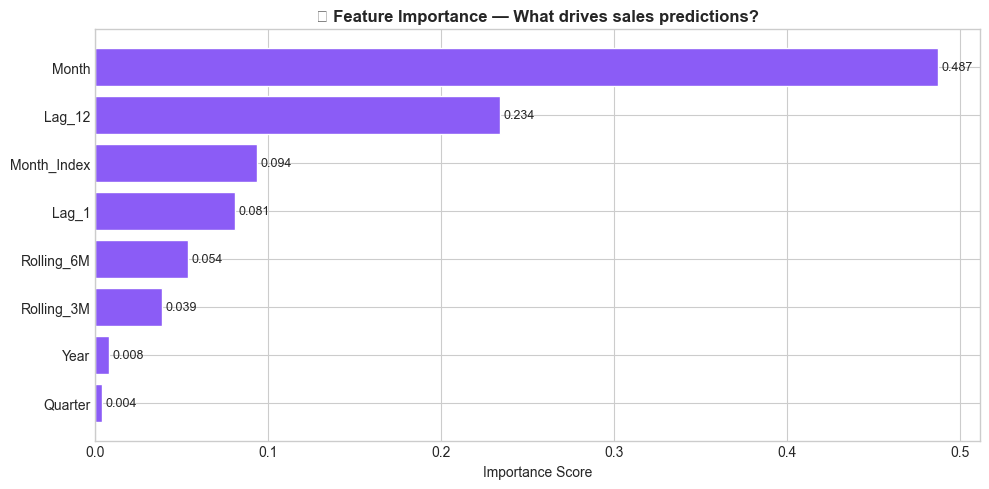

💾 Saved as feature_importance.png


In [18]:
importance_df = pd.DataFrame({
    'Feature':   feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color='#8B5CF6', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('🌲 Feature Importance — What drives sales predictions?', fontweight='bold')
for bar, val in zip(bars, importance_df['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved as feature_importance.png')

---
##  Step 9: Business Insights
This is what separates a good intern from a great one — **translating numbers into decisions**.

In [21]:
print('=' * 60)
print('        BUSINESS INSIGHTS REPORT')
print('=' * 60)

# Peak month
avg_monthly = df.groupby(df['Order Date'].dt.month)['Sales'].mean()
peak_month_num = avg_monthly.idxmax()
peak_month_name = month_names[peak_month_num - 1]
print(f'\n Peak Sales Month : {peak_month_name}')
print(f'   → Stock up inventory BEFORE {peak_month_name} to meet demand.')

# Slowest month
slow_month_num = avg_monthly.idxmin()
slow_month_name = month_names[slow_month_num - 1]
print(f'\n Slowest Month    : {slow_month_name}')
print(f'   → Consider promotions in {slow_month_name} to boost revenue.')

# Best category
best_cat = df.groupby('Category')['Sales'].sum().idxmax()
print(f'\n Top Category     : {best_cat}')
print(f'   → Focus marketing budget on {best_cat}.')

# Model accuracy
best_r2  = max(lr_r2, rf_r2)
best_mae = min(lr_mae, rf_mae)
print(f'\n Best Model R²    : {best_r2:.1%}')
print(f'   Avg Monthly Error: ${best_mae:,.0f}')
print(f'   → The model explains {best_r2:.1%} of sales variation.')
print(f'   → On average, predictions are off by ${best_mae:,.0f}/month.')

# Year-over-year growth
yearly = df.groupby(df['Order Date'].dt.year)['Sales'].sum()
if len(yearly) >= 2:
    yoy = (yearly.iloc[-1] - yearly.iloc[-2]) / yearly.iloc[-2] * 100
    print(f'\n YoY Sales Growth : {yoy:+.1f}%')
    trend = 'growing' if yoy > 0 else 'declining'
    print(f'   → Business is {trend}. Adjust forecasts accordingly.')

print('\n' + '=' * 60)

        BUSINESS INSIGHTS REPORT

 Peak Sales Month : Mar
   → Stock up inventory BEFORE Mar to meet demand.

 Slowest Month    : Feb
   → Consider promotions in Feb to boost revenue.

 Top Category     : Technology
   → Focus marketing budget on Technology.

 Best Model R²    : 56.5%
   Avg Monthly Error: $13,684
   → The model explains 56.5% of sales variation.
   → On average, predictions are off by $13,684/month.

 YoY Sales Growth : +20.3%
   → Business is growing. Adjust forecasts accordingly.

